# Example model visualization

In [1]:
import os, scipy.io 
import numpy as np 
import matplotlib.pyplot as plt 

import sys
sys.path.append('/home/nuttidalab/Documents/renee/spikeRNN/rate/')

import model

2026-02-20 01:26:13.542799: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-20 01:26:13.561666: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-02-20 01:26:13.580036: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-02-20 01:26:13.585481: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-02-20 01:26:13.602197: I tensorflow/core/platform/cpu_feature_guar

Instructions for updating:
non-resource variables are not supported in the long term


### load model

In [2]:
model_dir = '/home/nuttidalab/Documents/renee/sternberg'
# model_fname = 'Task_sternberg_N_400_Jitter_5_3_2026_02_13_035523.mat'
model_fname = 'Task_sternberg_N_400_Jitter_5_3_2026_02_13_160606.mat'
mat_data = scipy.io.loadmat(os.path.join(model_dir, model_fname))

In [6]:
for keys in mat_data.keys():
    print(keys)

__header__
__version__
__globals__
x0
r0
w0
taus_gaus0
w_in0
u
o
w
x
target
w_out
r
m
som_m
N
exc
inh
w_in
b_out
som_N
losses
taus
eval_perf_mean
eval_loss_mean
eval_os
eval_labels
taus_gaus
tr
activation
stim_on_tr
stim_dur_tr
p_low
eval_perfs
load
delay_tr
T_tr


In [3]:
# model_names = ['Task_sternberg_N_400_Jitter_5_3_2026_02_13_032322.mat',
#                'Task_sternberg_N_400_Jitter_5_3_2026_02_13_035523.mat']

model_names = ['Task_sternberg_N_400_Jitter_5_3_2026_02_13_160606.mat']

In [4]:
for model_name in model_names:
    mat_data = scipy.io.loadmat(os.path.join(model_dir, model_name))
    print(model_name)
    print(f'Training trials: {mat_data["tr"][0]}')
    print(f'Load 1 perf: {mat_data["eval_perfs"][0][0]}, Load 3 perf: {mat_data["eval_perfs"][0][1]}')
    print(f'Ending p_low: {mat_data["p_low"][0]}')


Task_sternberg_N_400_Jitter_5_3_2026_02_13_160606.mat
Training trials: [29999]
Load 1 perf: 0.76, Load 3 perf: 0.79
Ending p_low: [0.2]


### Visualize outputs

[[3]]


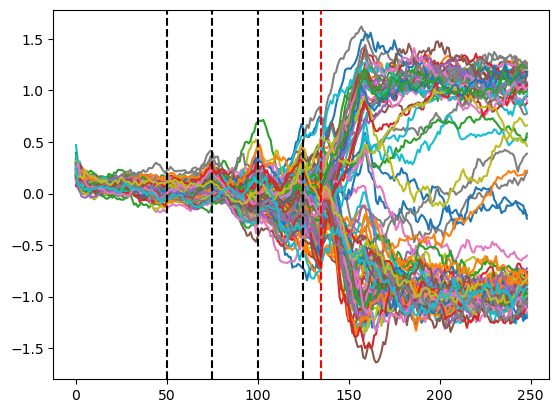

In [6]:
plt.figure()
plt.plot(np.transpose(mat_data['eval_os'][:,]))
stim_on = mat_data['stim_on_tr'][0]
stim_dur = mat_data['stim_dur_tr'][0]
delay = mat_data['delay_tr'][0]
plt.axvline(x=stim_on, color='k', linestyle='--')
for i in range(mat_data['load'][0][0]):
    plt.axvline(x=stim_on + (i+1)*stim_dur, color='k', linestyle='--')
plt.axvline(x=stim_on + stim_dur*mat_data['load'][0][0] + delay, color='r', linestyle='--')
print(mat_data['load'])
plt.show()

[[3]]


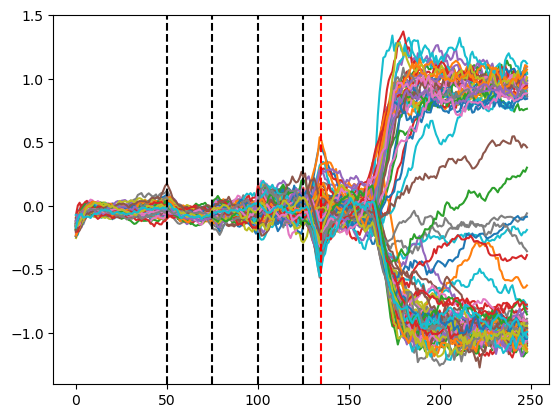

In [5]:
plt.figure()
plt.plot(np.transpose(mat_data['eval_os'][:,]))
stim_on = mat_data['stim_on_tr'][0]
stim_dur = mat_data['stim_dur_tr'][0]
delay = mat_data['delay_tr'][0]
plt.axvline(x=stim_on, color='k', linestyle='--')
for i in range(mat_data['load'][0][0]):
    plt.axvline(x=stim_on + (i+1)*stim_dur, color='k', linestyle='--')
plt.axvline(x=stim_on + stim_dur*mat_data['load'][0][0] + delay, color='r', linestyle='--')
print(mat_data['load'])
plt.show()

### model eval

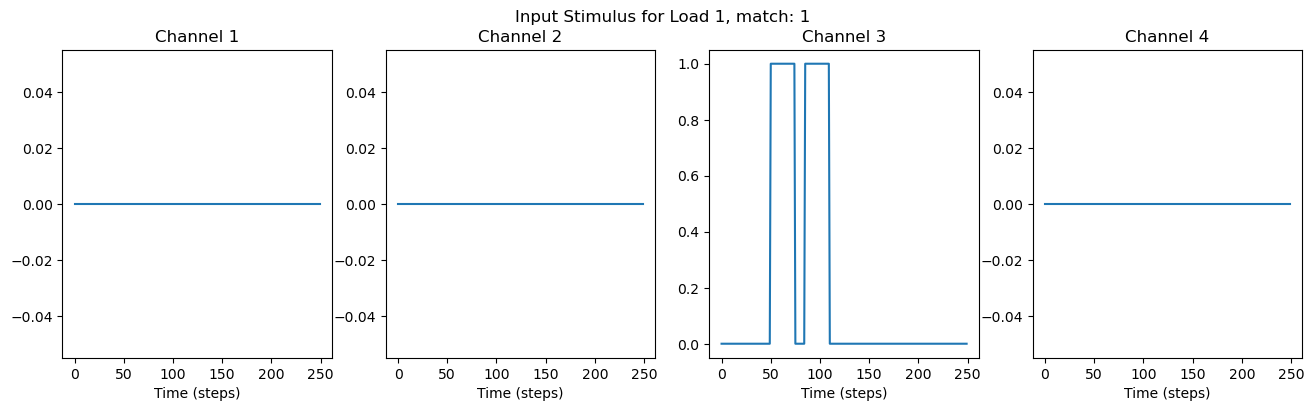

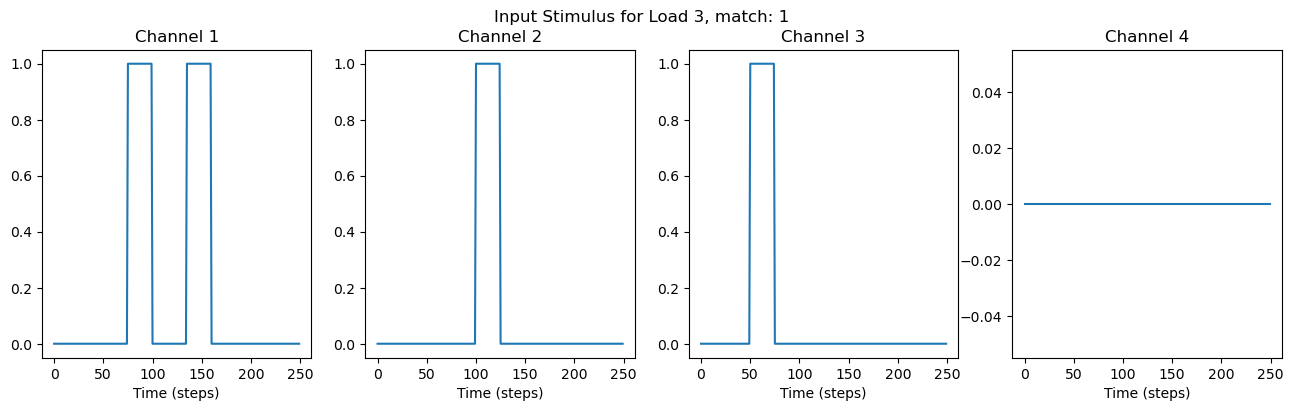

In [ ]:
from model import generate_input_stim_sternberg

settings = {
            'T': 250, # trial duration (in steps)
            'stim_on': 50, # input stim onset (in steps)
            'stim_dur': 25, # input stim duration (in steps)
            'delay': 10, # delay b/w sample and test (in steps)
            'DeltaT': 1, # sampling rated
            'load': 1, # initialize with load 1, but will alternate with 3
            }

u_low, label = generate_input_stim_sternberg(settings)

fig, axs = plt.subplots(1, 4, figsize=(16,4))
for i in range(4):
    axs[i].plot(u_low[i,:])
    axs[i].set_title(f'Channel {i+1}')
    axs[i].set_xlabel('Time (steps)')
plt.suptitle(f'Input Stimulus for Load 1, match: {label}')

settings['load'] = 3
u_high, label = generate_input_stim_sternberg(settings)
fig, axs = plt.subplots(1, 4, figsize=(16,4))
for i in range(4):
    axs[i].plot(u_high[i,:])
    axs[i].set_title(f'Channel {i+1}')
    axs[i].set_xlabel('Time (steps)')
plt.suptitle(f'Input Stimulus for Load 3, match: {label}')

plt.show()

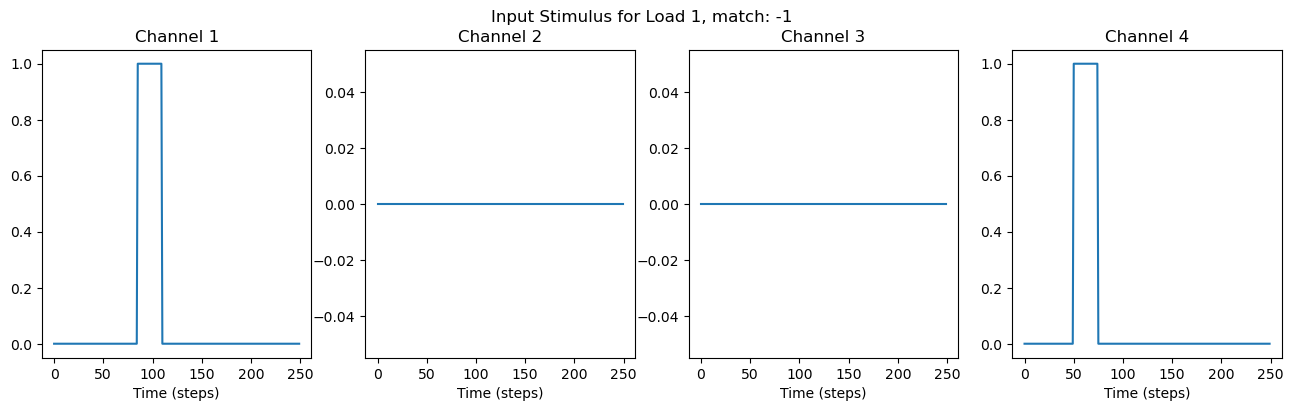

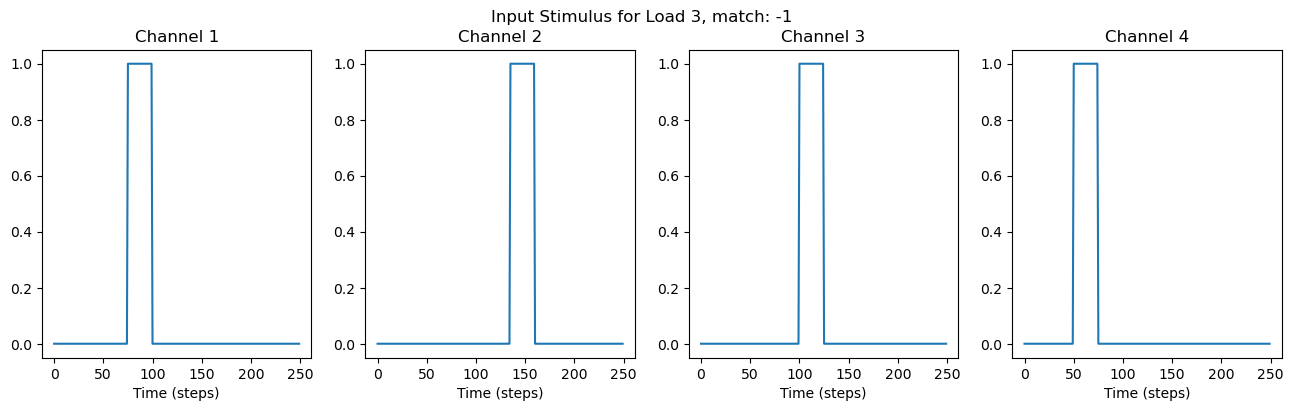

In [11]:
settings = {
            'T': 250, # trial duration (in steps)
            'stim_on': 50, # input stim onset (in steps)
            'stim_dur': 25, # input stim duration (in steps)
            'delay': 10, # delay b/w sample and test (in steps)
            'DeltaT': 1, # sampling rated
            'load': 1, # initialize with load 1, but will alternate with 3
            }

u_low, label = generate_input_stim_sternberg(settings)

fig, axs = plt.subplots(1, 4, figsize=(16,4))
for i in range(4):
    axs[i].plot(u_low[i,:])
    axs[i].set_title(f'Channel {i+1}')
    axs[i].set_xlabel('Time (steps)')
plt.suptitle(f'Input Stimulus for Load 1, match: {label}')

settings['load'] = 3
u_high, label = generate_input_stim_sternberg(settings)
fig, axs = plt.subplots(1, 4, figsize=(16,4))
for i in range(4):
    axs[i].plot(u_high[i,:])
    axs[i].set_title(f'Channel {i+1}')
    axs[i].set_xlabel('Time (steps)')
plt.suptitle(f'Input Stimulus for Load 3, match: {label}')

plt.show()

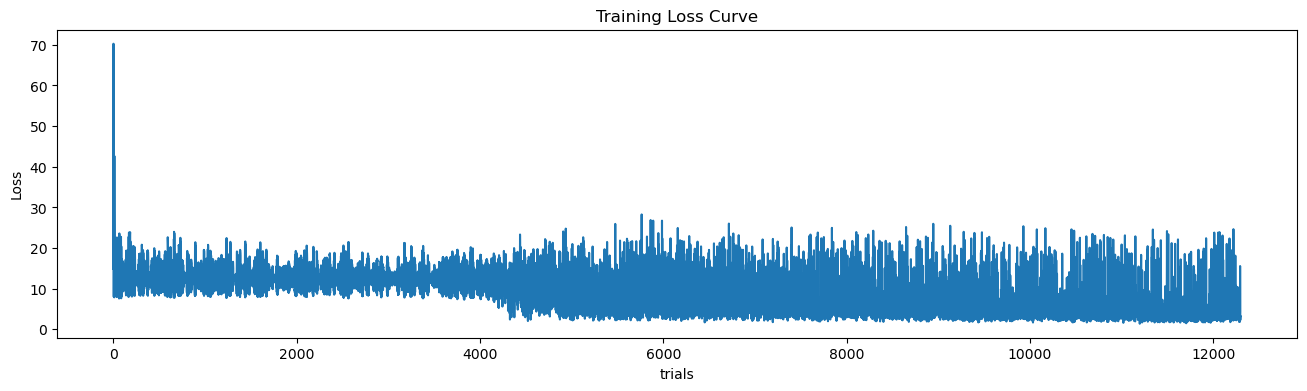

In [16]:
# plot training loss

losses = mat_data['losses'][0]
plt.figure(figsize=(16,4))
plt.plot(losses[:mat_data['tr'][0][0]])
plt.xlabel('trials')
plt.ylabel('Loss')
plt.title('Training Loss Curve')
plt.show()

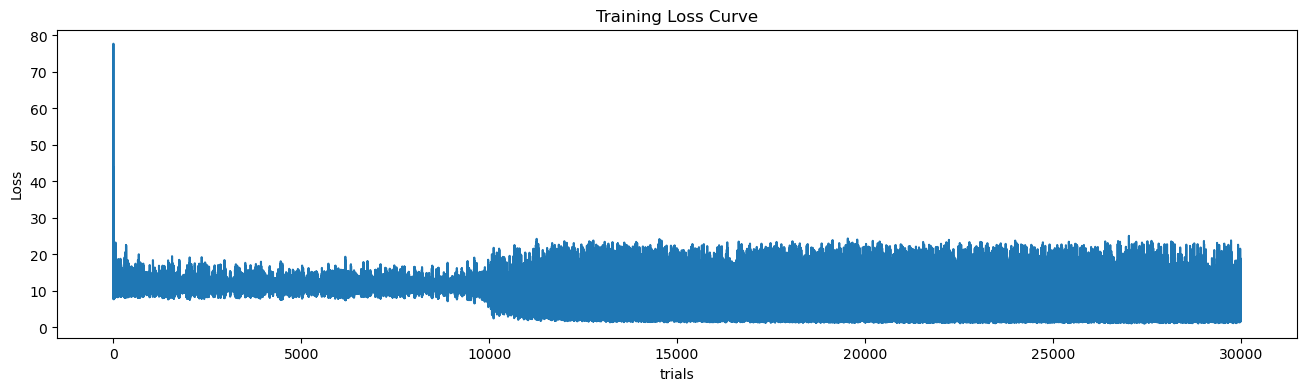

In [6]:
# plot training loss

losses = mat_data['losses'][0]
plt.figure(figsize=(16,4))
plt.plot(losses[:mat_data['tr'][0][0]])
plt.xlabel('trials')
plt.ylabel('Loss')
plt.title('Training Loss Curve')
plt.show()

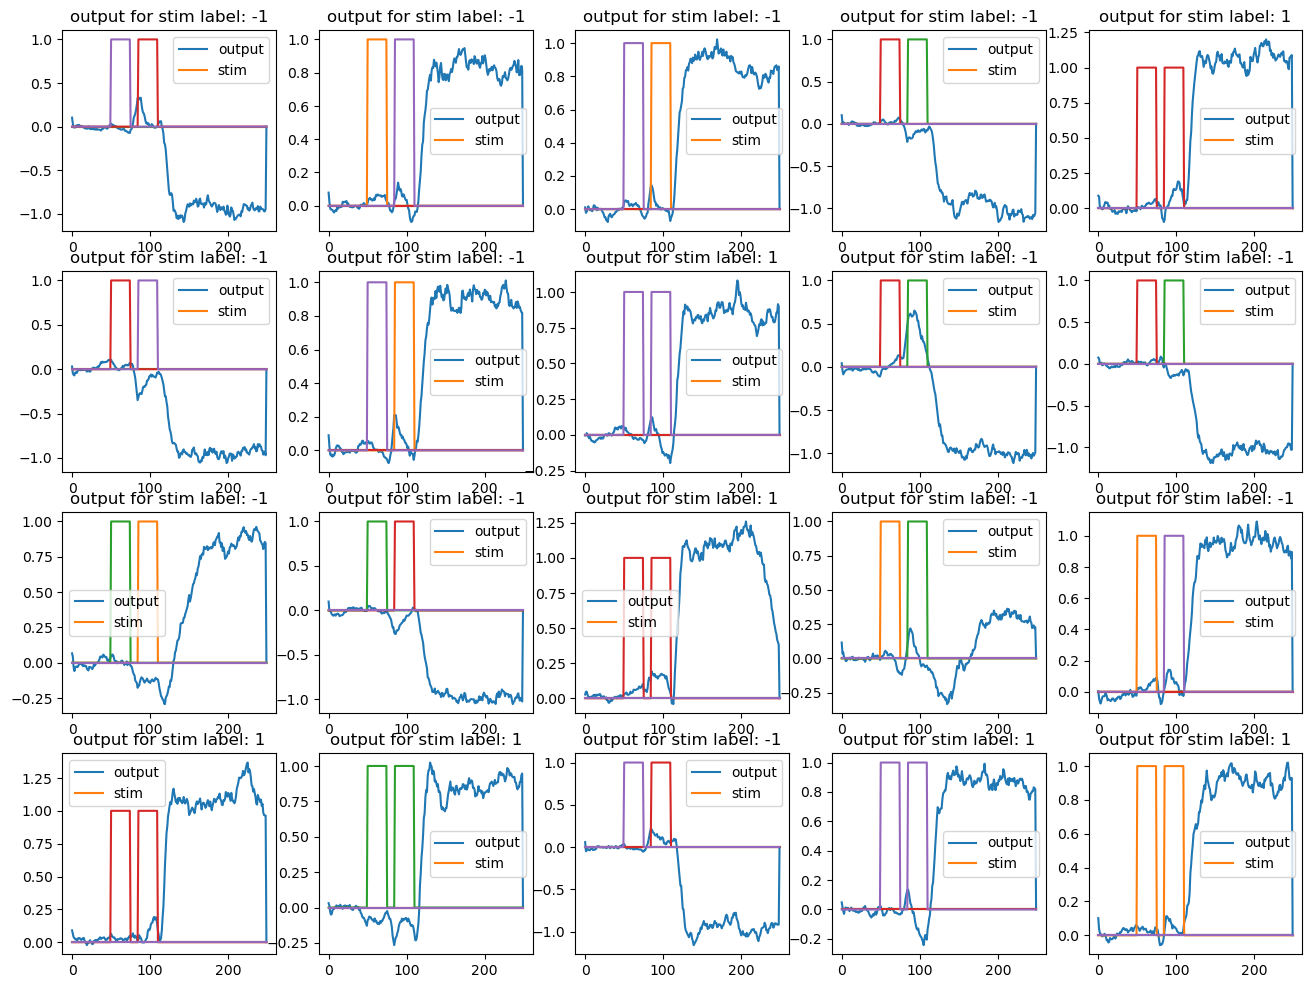

In [ ]:
settings = {
            'T': 250, # trial duration (in steps)
            'stim_on': 50, # input stim onset (in steps)
            'stim_dur': 25, # input stim duration (in steps)
            'delay': 10, # delay b/w sample and test (in steps)
            'DeltaT': 1, # sampling rated
            'load': 1, # initialize with load 1, but will alternate with 3
            }

n_trials = 20
fig, axs = plt.subplots(4, 5, figsize=(16, 12), sharex=True)
axs = axs.flatten()
for j in range(n_trials):

    u_low, label = model.generate_input_stim_sternberg(settings)

    x, r, o, _ = model.eval_tf(model_dir=f'{model_dir}/{model_fname}', settings=settings, u=u_low)

    axs[j].plot(o)
    for i in range(u_low.shape[0]):
        axs[j].plot(u_low[i,:])
    axs[j].set_title(f'output for stim label: {label}')
    axs[j].legend(['output','stim'])
plt.show()

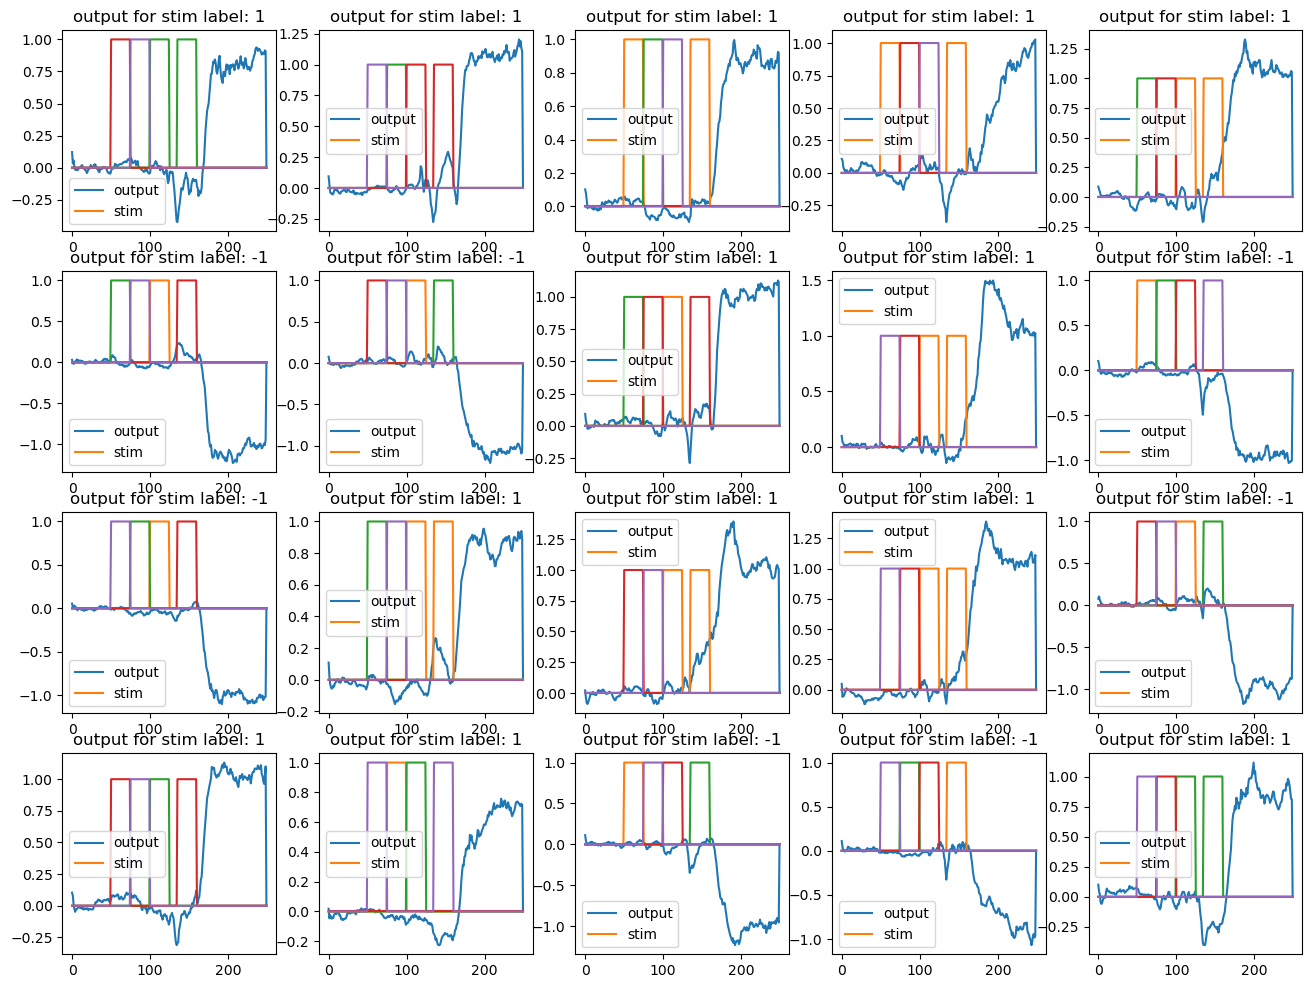

In [ ]:
settings = {
            'T': 250, # trial duration (in steps)
            'stim_on': 50, # input stim onset (in steps)
            'stim_dur': 25, # input stim duration (in steps)
            'delay': 10, # delay b/w sample and test (in steps)
            'DeltaT': 1, # sampling rated
            'load': 3, # initialize with load 1, but will alternate with 3
            }

n_trials = 20
fig, axs = plt.subplots(4, 5, figsize=(16, 12), sharex=True)
axs = axs.flatten()
for j in range(n_trials):
    u_high, label = model.generate_input_stim_sternberg(settings)
    x, r, o, _ = model.eval_tf(model_dir=f'{model_dir}/{model_fname}', settings=settings, u=u_high)

    axs[j].plot(o)
    for i in range(u_high.shape[0]):
        axs[j].plot(u_high[i,:])
    axs[j].set_title(f'output for stim label: {label}')
    axs[j].legend(['output','stim'])
plt.show()

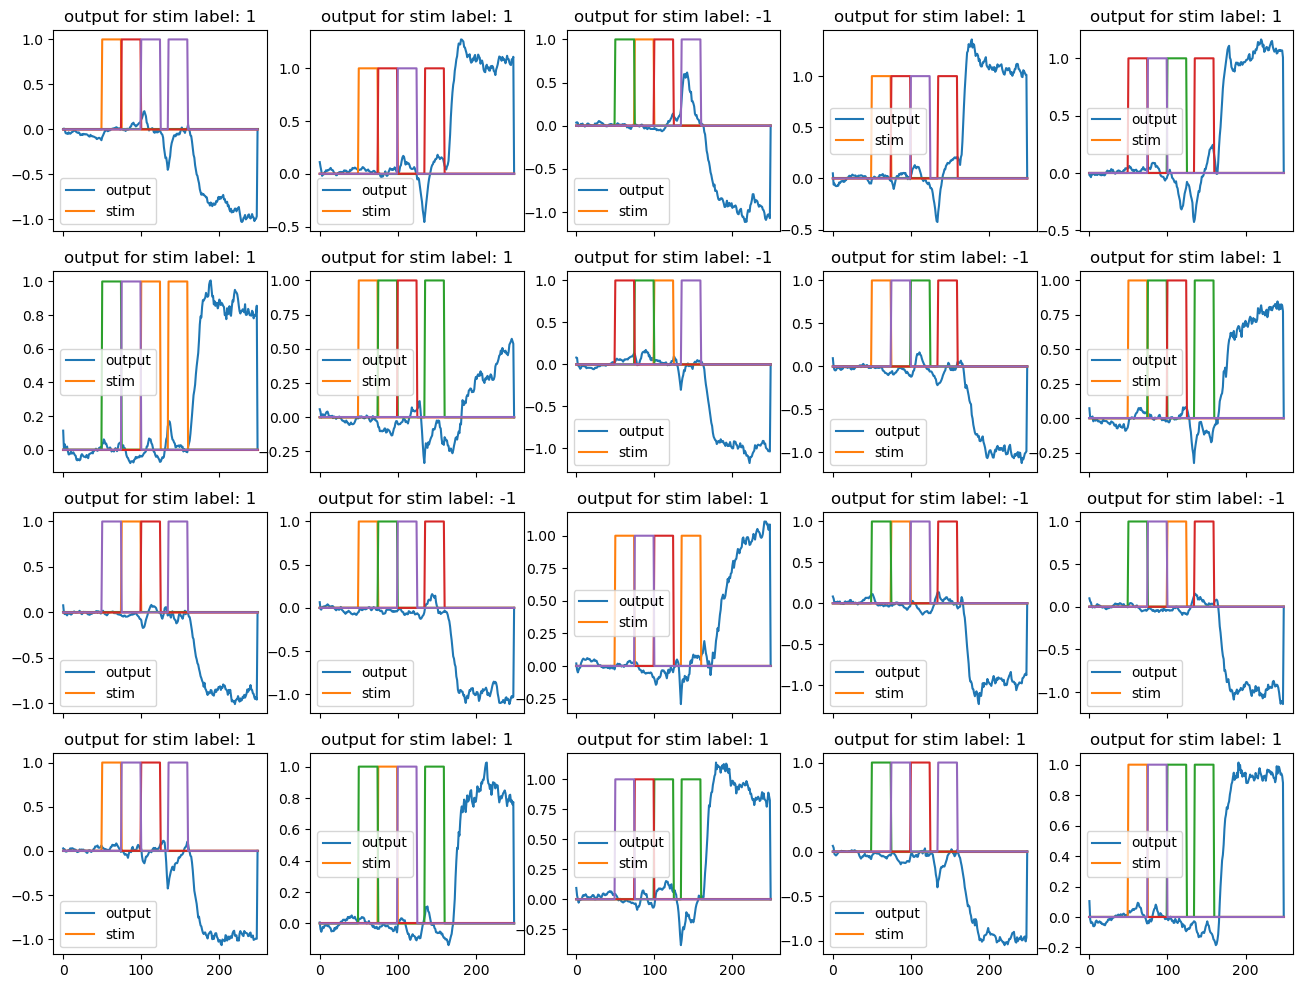

In [15]:
settings = {
            'T': 250, # trial duration (in steps)
            'stim_on': 50, # input stim onset (in steps)
            'stim_dur': 25, # input stim duration (in steps)
            'delay': 10, # delay b/w sample and test (in steps)
            'DeltaT': 1, # sampling rated
            'load': 3, # initialize with load 1, but will alternate with 3
            }

n_trials = 20
fig, axs = plt.subplots(4, 5, figsize=(16, 12), sharex=True)
axs = axs.flatten()
for j in range(n_trials):
    u_high, label = model.generate_input_stim_sternberg(settings)
    x, r, o, _ = model.eval_tf(model_dir=f'{model_dir}/{model_fname}', settings=settings, u=u_high)

    axs[j].plot(o)
    for i in range(u_high.shape[0]):
        axs[j].plot(u_high[i,:])
    axs[j].set_title(f'output for stim label: {label}')
    axs[j].legend(['output','stim'])
plt.show()

In [73]:
# model eval on 100 random trials

n_trials = 100
resp_onset = settings['stim_on'] + settings['stim_dur']
eval_amp_threshold = 0.7
eval_perf = np.zeros(n_trials)

for i in range(n_trials):
    eval_u, eval_label = generate_input_stim_go_nogo(settings)
    _, _, eval_o = model.eval_tf(model_dir=f'{model_dir}/{model_fname}', settings=settings, u=eval_u)
    if eval_label == 1:
        if np.max(eval_o[resp_onset:]) > eval_amp_threshold:
            eval_perf[i] = 1
    else:
        if np.max(np.abs(eval_o[resp_onset:])) < 0.3:
            eval_perf[i] = 1

eval_perf_mean = np.nanmean(eval_perf)
print("Performance: %.2f"%(eval_perf_mean))

Performance: 1.00


### another model, this time target not 10 steps after probe


In [2]:
model_dir = '/home/nuttidalab/Documents/renee/sternberg/singleload_1'
model_fname = 'Task_sternberg_Load_1_N_400_Jitter_5_3_2026_02_19_225119.mat'
mat_data = scipy.io.loadmat(os.path.join(model_dir, model_fname))

In [3]:
model_names = ['Task_sternberg_Load_1_N_400_Jitter_5_3_2026_02_19_225119.mat',
               'Task_sternberg_Load_1_N_400_Jitter_5_3_2026_02_20_004329.mat']

In [4]:
for model_name in model_names:
    mat_data = scipy.io.loadmat(os.path.join(model_dir, model_name))
    print(model_name)
    print(f'Training trials: {mat_data["tr"][0]}')


Task_sternberg_Load_1_N_400_Jitter_5_3_2026_02_19_225119.mat
Training trials: [14001]
Task_sternberg_Load_1_N_400_Jitter_5_3_2026_02_20_004329.mat
Training trials: [15101]


### Visualize outputs

[[1]]


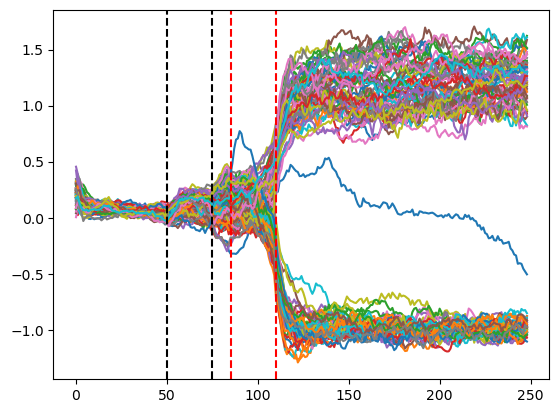

In [6]:
plt.figure()
plt.plot(np.transpose(mat_data['eval_os'][:,]))
stim_on = mat_data['stim_on_tr'][0]
stim_dur = mat_data['stim_dur_tr'][0]
delay = mat_data['delay_tr'][0]
plt.axvline(x=stim_on, color='k', linestyle='--')
for i in range(mat_data['load'][0][0]):
    plt.axvline(x=stim_on + (i+1)*stim_dur, color='k', linestyle='--')
plt.axvline(x=stim_on + stim_dur*mat_data['load'][0][0] + delay, color='r', linestyle='--')
plt.axvline(x=stim_on + stim_dur*mat_data['load'][0][0] + delay + stim_dur, color='r', linestyle='--')
print(mat_data['load'])
plt.show()

### model eval

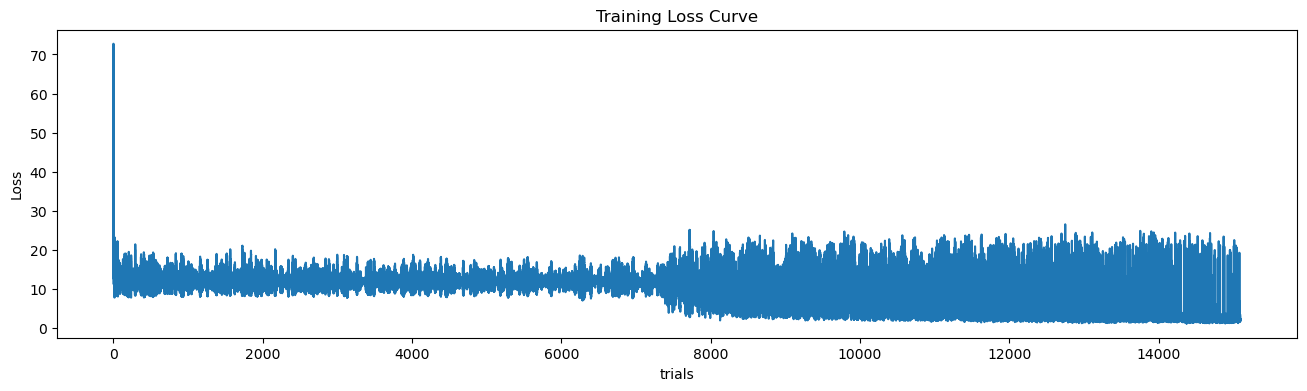

In [7]:
# plot training loss

losses = mat_data['losses'][0]
plt.figure(figsize=(16,4))
plt.plot(losses[:mat_data['tr'][0][0]])
plt.xlabel('trials')
plt.ylabel('Loss')
plt.title('Training Loss Curve')
plt.show()

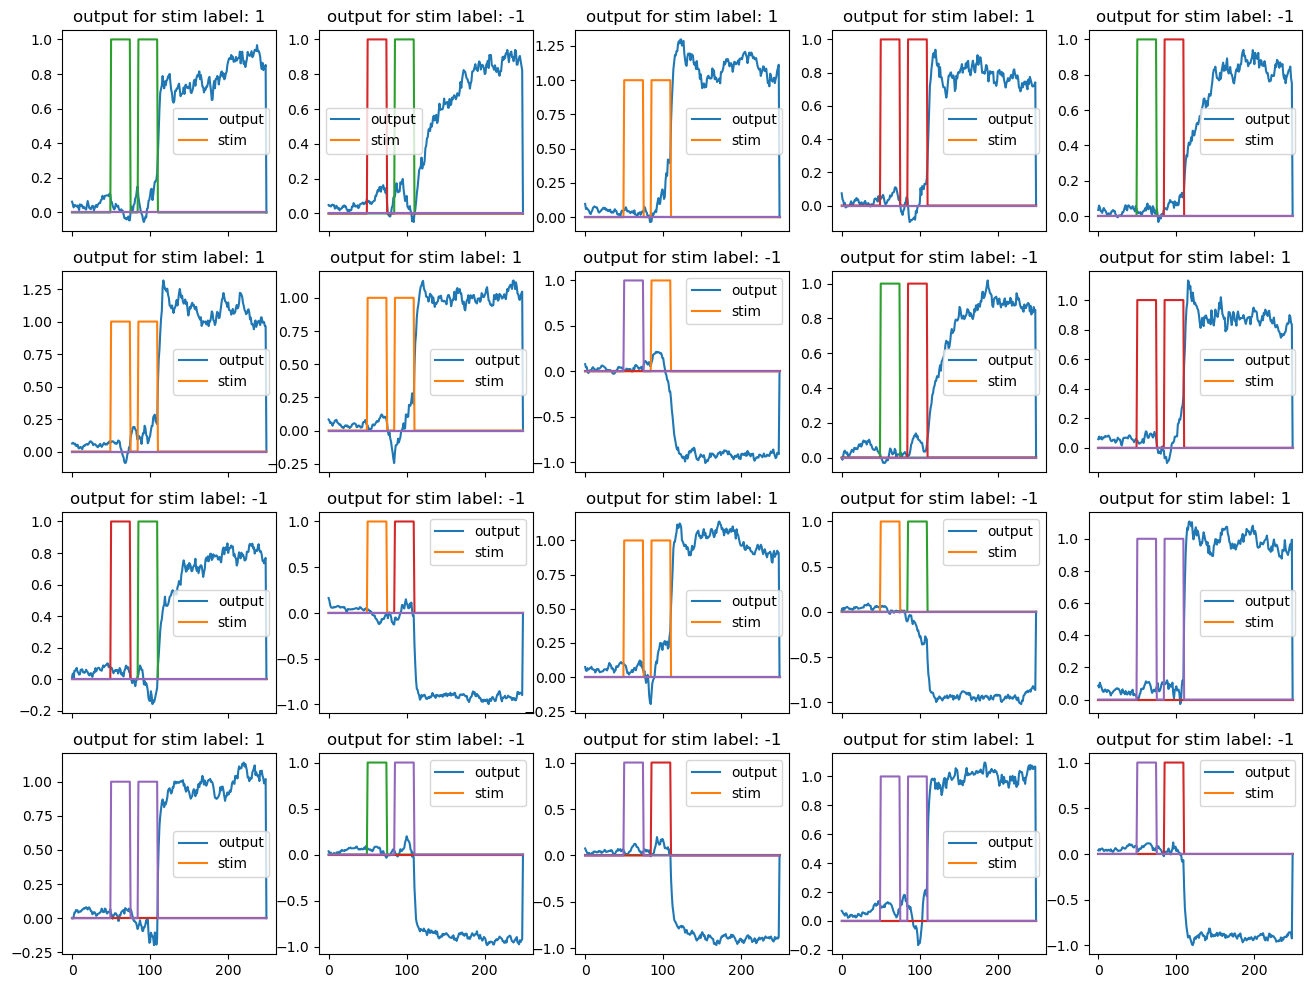

In [8]:
from model import generate_input_stim_sternberg

settings = {
            'T': 250, # trial duration (in steps)
            'stim_on': 50, # input stim onset (in steps)
            'stim_dur': 25, # input stim duration (in steps)
            'delay': 10, # delay b/w sample and test (in steps)
            'DeltaT': 1, # sampling rated
            'load': 1, # initialize with load 1, but will alternate with 3
            }

n_trials = 20
fig, axs = plt.subplots(4, 5, figsize=(16, 12), sharex=True)
axs = axs.flatten()
for j in range(n_trials):

    u_low, label = model.generate_input_stim_sternberg(settings)

    x, r, o, _ = model.eval_tf(model_dir=f'{model_dir}/{model_fname}', settings=settings, u=u_low)

    axs[j].plot(o)
    for i in range(u_low.shape[0]):
        axs[j].plot(u_low[i,:])
    axs[j].set_title(f'output for stim label: {label}')
    axs[j].legend(['output','stim'])
plt.show()

### plotting model firing rates r, and synaptic current x

In [59]:
mat_data.keys()

dict_keys(['__header__', '__version__', '__globals__', 'x0', 'r0', 'w0', 'taus_gaus0', 'w_in0', 'u', 'o', 'w', 'x', 'target', 'w_out', 'r', 'm', 'som_m', 'N', 'exc', 'inh', 'w_in', 'b_out', 'som_N', 'losses', 'taus', 'eval_perf_mean', 'eval_loss_mean', 'eval_os', 'eval_labels', 'taus_gaus', 'tr', 'activation'])

In [360]:
r = mat_data['r']
x = mat_data['x']
print(r.shape)
print(x.shape)

(200, 200, 1)
(200, 200, 1)


In [7]:
exc = mat_data['exc']
exc_ind = np.where(exc == 1)[0]
inh = mat_data['inh']
inh_ind = np.where(inh == 1)[0]
print(inh_ind)

[  4   8   9  14  16  19  21  31  40  42  44  51  59  62  67  70  71  75
  76  77  80  88  92 101 102 103 107 121 123 124 129 130 132 133 138 142
 153 154 159 174 178 180 187 192 193 195]


### Trajectory plots

In [12]:

from sklearn.decomposition import PCA


In [13]:
r = mat_data['r'][:,:,0]
r.shape

(200, 200)

In [18]:
resp_onset = settings['stim_on'] + settings['stim_dur']

X (r): time x neurons  

U: time x n_components  

S: n_components  

Vt: n_components x neurons  

In [39]:
# X = USVt

pca = PCA(n_components=100).fit(r)
r_U = pca.transform(r)
r_S = pca.singular_values_
r_Vt = pca.components_

print(r_U.shape)
print(r_S.shape)
print(r_Vt.shape)

(200, 100)
(100,)
(100, 200)


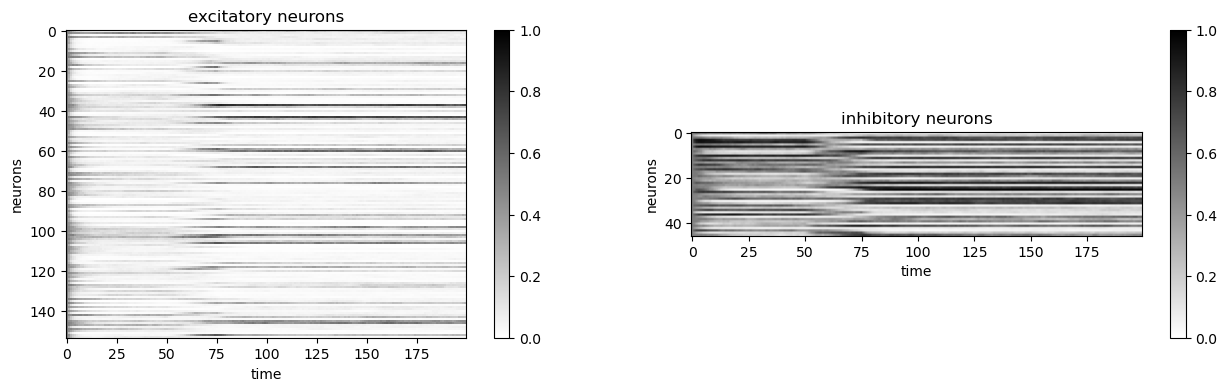

In [15]:
fig,axs = plt.subplots(1,2,figsize=(16,4))
im1 = axs[0].imshow(r[:,exc_ind].T,cmap='binary',vmin=0, vmax=1)
axs[0].set_xlabel('time')
axs[0].set_ylabel('neurons')
axs[0].set_title('excitatory neurons')
fig.colorbar(im1)

im2 = axs[1].imshow(r[:,inh_ind].T,cmap='binary',vmin=0, vmax=1)
axs[1].set_xlabel('time')
axs[1].set_ylabel('neurons')
axs[1].set_title('inhibitory neurons')
fig.colorbar(im2)

plt.show()

In [28]:
from mpl_toolkits.mplot3d import axes3d
%matplotlib inline 
# %matplotlib widget

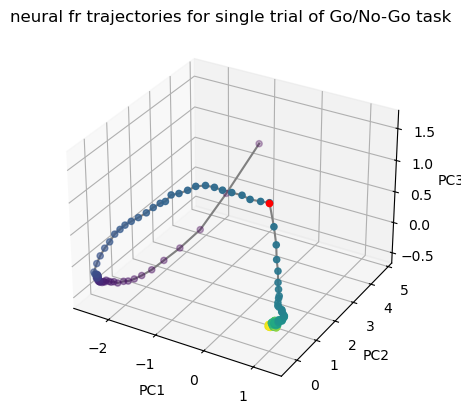

In [29]:
ax = plt.figure().add_subplot(projection='3d')
ax.scatter(r_U[:,0], r_U[:,1], r_U[:,2], c=range(200))
ax.plot3D(r_U[:,0], r_U[:,1], r_U[:,2], 'gray')
ax.scatter(r_U[resp_onset,0], r_U[resp_onset,1], r_U[resp_onset,2], c='r')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.set_title('neural fr trajectories for single trial of Go/No-Go task')
plt.show()